# Full PPS Surrogate Validation — Processed PPG

Mục tiêu: đánh giá toàn bộ kết quả PPS surrogate testing sau production, với
`window_results` là nguồn phân tích chính và `surrogate_results` chỉ dùng cho
kiểm tra chất lượng/diagnostic.

- **Primary metrics:** CC, DET, LAM
- **Secondary metrics:** NRMSE, Lmean, ENTR, Lmax, TT, Vmax
- Formal test đã được thực hiện ở **window level**: $M=39$ PPS/window,
  two-sided rank test, $\alpha=0.05$.
- Session là đơn vị replication chính.

Notebook không chạy lại PPS và không tính lại metric. Mọi table/figure được hiển
thị inline; chỉ ba figure chính được lưu ở dạng publication-ready (PDF vector và
PNG 600 dpi) trong `phase1/results/statistic/validation`.

In [1]:
# Cell 1 — Dataset analysis có đầy đủ không?
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter

METRICS = ["CC", "DET", "LAM", "NRMSE", "Lmean", "ENTR", "Lmax", "TT", "Vmax"]
PRIMARY = ["CC", "DET", "LAM"]
SECONDARY = [metric for metric in METRICS if metric not in PRIMARY]
WINDOW_KEYS = ["session", "representation", "state", "window_size", "window_id"]
EXPECTED_M = 39
ALPHA = 0.05


def find_project_root(start=Path.cwd()):
    # Find the repository root regardless of the notebook launch directory.
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "phase1" / "results" / "statistic" / "processed").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate phase1/results/statistic/processed")


PROJECT_ROOT = find_project_root()
RESULTS_DIR = PROJECT_ROOT / "phase1" / "results" / "statistic" / "processed"
FIGURE_DIR = PROJECT_ROOT / "phase1" / "results" / "statistic" / "validation"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PUBLICATION_DPI = 600
METRIC_COLORS = {"CC": "#0072B2", "DET": "#009E73", "LAM": "#D55E00"}


def save_publication_figure(fig, stem):
    """Save one named figure as editable PDF and high-resolution PNG."""
    pdf_path = FIGURE_DIR / f"{stem}.pdf"
    png_path = FIGURE_DIR / f"{stem}.png"
    fig.savefig(pdf_path, bbox_inches="tight", facecolor="white")
    fig.savefig(png_path, dpi=PUBLICATION_DPI, bbox_inches="tight", facecolor="white")
    print(f"Saved publication figure: {pdf_path}")
    print(f"Saved publication figure: {png_path}")

window_files = sorted(RESULTS_DIR.glob("session_*_processed_pps_window_results.csv"))
surrogate_files = sorted(RESULTS_DIR.glob("session_*_processed_pps_surrogate_results.csv"))
if not window_files or not surrogate_files:
    raise FileNotFoundError(f"No production PPS result files found in {RESULTS_DIR}")

windows_all = pd.concat((pd.read_csv(path) for path in window_files), ignore_index=True)
surrogates_all = pd.concat((pd.read_csv(path) for path in surrogate_files), ignore_index=True)
windows_all = windows_all.sort_values(WINDOW_KEYS, kind="stable").reset_index(drop=True)
surrogates_all = surrogates_all.sort_values(
    WINDOW_KEYS + ["surrogate_id"], kind="stable"
).reset_index(drop=True)

dataset_counts = pd.DataFrame(
    {
        "Quantity": [
            "Sessions", "Windows", "Surrogate rows", "Expected surrogate rows"
        ],
        "N": [
            windows_all["session"].nunique(), len(windows_all), len(surrogates_all),
            len(windows_all) * EXPECTED_M,
        ],
    }
)
display(dataset_counts)
display(
    windows_all.groupby(["state", "window_size"], observed=True)
    .size().unstack(fill_value=0).rename_axis(index="State", columns="Window size (s)")
)

,Quantity,N
0,Sessions,20
1,Windows,1544
2,Surrogate rows,60216
3,Expected surrogate rows,60216


Window size (s),60,120,180
State,,,
Awake,596,269,161
Drowsy,305,136,77


In [2]:
# Cell 2 — Toàn bộ input có vượt qua global integrity check không?
window_group_sizes = surrogates_all.groupby(WINDOW_KEYS, observed=True).size()
surrogate_id_counts = surrogates_all.groupby(WINDOW_KEYS, observed=True)["surrogate_id"].nunique()
seed_counts = surrogates_all.groupby(WINDOW_KEYS, observed=True)["seed"].nunique()
window_identity = pd.MultiIndex.from_frame(windows_all[WINDOW_KEYS])
surrogate_identity = pd.MultiIndex.from_frame(surrogates_all[WINDOW_KEYS].drop_duplicates())

checks = {
    "Windows unique (1 row/window)": not windows_all.duplicated(WINDOW_KEYS).any(),
    "Window identities match across files": set(window_identity) == set(surrogate_identity),
    "39 PPS rows/window": window_group_sizes.eq(EXPECTED_M).all(),
    "39 unique surrogate_id/window": surrogate_id_counts.eq(EXPECTED_M).all(),
    "39 unique seeds/window": seed_counts.eq(EXPECTED_M).all(),
    "Original metrics finite": np.isfinite(
        windows_all[[f"{m}_original" for m in METRICS]].to_numpy(dtype=float)
    ).all(),
    "Surrogate medians finite": np.isfinite(
        windows_all[[f"{m}_surrogate_median" for m in METRICS]].to_numpy(dtype=float)
    ).all(),
    "All surrogate metrics finite": np.isfinite(
        surrogates_all[METRICS].to_numpy(dtype=float)
    ).all(),
    "All p-values finite": np.isfinite(
        windows_all[[f"{m}_p" for m in METRICS]].to_numpy(dtype=float)
    ).all(),
    "M == 39": windows_all["M"].eq(EXPECTED_M).all(),
}
integrity_table = pd.DataFrame(
    {"Check": list(checks), "Result": ["PASS" if value else "FAIL" for value in checks.values()]}
)
display(integrity_table)
failed_checks = [name for name, passed in checks.items() if not passed]
if failed_checks:
    raise AssertionError("Integrity check failed; analysis stopped: " + "; ".join(failed_checks))
print("All integrity checks passed. Analysis may proceed.")

,Check,Result
0,Windows unique (1 row/window),PASS
1,Window identities match across files,PASS
2,39 PPS rows/window,PASS
3,39 unique surrogate_id/window,PASS
4,39 unique seeds/window,PASS
5,Original metrics finite,PASS
6,Surrogate medians finite,PASS
7,All surrogate metrics finite,PASS
8,All p-values finite,PASS
9,M == 39,PASS


All integrity checks passed. Analysis may proceed.


In [3]:
# Cell 3 — Metric nào cho evidence mạnh nhất chống PPS null, và theo hướng nào?
long_parts = []
for metric in METRICS:
    part = windows_all[WINDOW_KEYS].copy()
    part["metric"] = metric
    part["original"] = windows_all[f"{metric}_original"].astype(float)
    part["surrogate_median"] = windows_all[f"{metric}_surrogate_median"].astype(float)
    part["p"] = windows_all[f"{metric}_p"].astype(float)
    part["reject"] = windows_all[f"{metric}_reject"].astype(bool)
    part["delta"] = part["original"] - part["surrogate_median"]
    long_parts.append(part)
metric_long = pd.concat(long_parts, ignore_index=True)


def dominant_direction(n_positive, n_negative, n_zero=0):
    # Return the majority sign; equal positive/negative counts are mixed.
    if n_positive > n_negative:
        return "positive"
    if n_negative > n_positive:
        return "negative"
    if n_positive == n_negative == 0 and n_zero > 0:
        return "zero"
    return "mixed"


def summarize_long(data, group_columns):
    # Summarize formal evidence and delta direction without rerunning any test.
    rows = []
    grouper = group_columns[0] if len(group_columns) == 1 else group_columns
    for keys, group in data.groupby(grouper, observed=True, sort=False, dropna=False):
        keys = (keys,) if len(group_columns) == 1 else keys
        delta = group["delta"].to_numpy(dtype=float)
        n_positive = int(np.sum(delta > 0))
        n_negative = int(np.sum(delta < 0))
        n_zero = int(np.sum(delta == 0))
        row = dict(zip(group_columns, keys))
        row.update(
            {
                "N": len(group),
                "N reject": int(group["reject"].sum()),
                "Rejection fraction": float(group["reject"].mean()),
                "N original > surrogate median": n_positive,
                "N original < surrogate median": n_negative,
                "N ties": n_zero,
                # Ties remain in the denominator, so they cannot inflate consistency.
                "Direction consistency": max(n_positive, n_negative) / len(group),
                "Dominant direction": dominant_direction(n_positive, n_negative, n_zero),
                "Median delta": float(np.median(delta)),
                "IQR delta": float(np.quantile(delta, 0.75) - np.quantile(delta, 0.25)),
                "Median p": float(group["p"].median()),
            }
        )
        rows.append(row)
    return pd.DataFrame(rows)


global_summary = summarize_long(metric_long, ["metric"])
global_summary["_order"] = global_summary["metric"].map({m: i for i, m in enumerate(METRICS)})
global_summary = global_summary.sort_values("_order").drop(columns="_order").reset_index(drop=True)
display(global_summary.round(4))

,metric,N,N reject,Rejection fraction,N original > surrogate median,N original < surrogate median,N ties,Direction consistency,Dominant direction,Median delta,IQR delta,Median p
0,CC,1544,1142,0.7396,1536,8,0,0.9948,positive,0.1257,0.1048,0.05
1,DET,1544,1539,0.9968,1544,0,0,1.0000,positive,0.1762,0.0457,0.05
2,LAM,1544,1388,0.8990,22,1522,0,0.9858,negative,-0.1125,0.0638,0.05
3,NRMSE,1544,1467,0.9501,2,1542,0,0.9987,negative,-0.1471,0.0724,0.05
4,Lmean,1544,1536,0.9948,1542,2,0,0.9987,positive,1.1143,0.2215,0.05
5,ENTR,1544,1527,0.9890,1542,2,0,0.9987,positive,0.3374,0.1168,0.05
6,Lmax,1544,1419,0.9190,1542,2,0,0.9987,positive,55.0000,32.0000,0.05
7,TT,1544,1498,0.9702,4,1540,0,0.9974,negative,-0.1058,0.0691,0.05
8,Vmax,1544,457,0.2960,63,941,540,0.6095,negative,-1.0000,1.0000,0.55


Saved publication figure: /home/vutu0809/Desktop/NTSA_Foundation/phase1/results/statistic/validation/figure1_primary_delta_distributions.pdf
Saved publication figure: /home/vutu0809/Desktop/NTSA_Foundation/phase1/results/statistic/validation/figure1_primary_delta_distributions.png


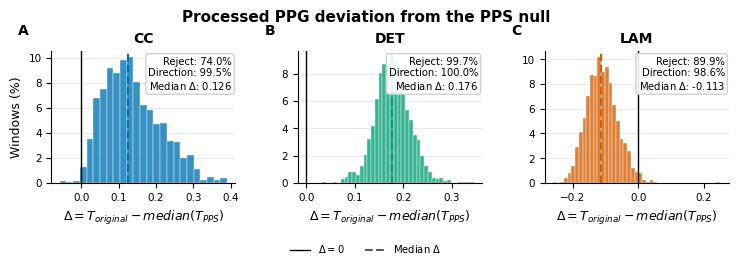

In [4]:
# Cell 4 — Magnitude và hướng của primary evidence trên toàn dataset trông như thế nào?
publication_style = {
    "font.family": "DejaVu Sans",
    "font.size": 8.5,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}

with plt.rc_context(publication_style):
    fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.75))
    fig.subplots_adjust(left=0.075, right=0.99, bottom=0.30, top=0.78, wspace=0.34)
    summary_lookup = global_summary.set_index("metric")

    for panel, ax, metric in zip("ABC", axes, PRIMARY):
        values = metric_long.loc[metric_long["metric"].eq(metric), "delta"].to_numpy()
        weights = np.full(len(values), 100.0 / len(values))
        bins = np.histogram_bin_edges(values, bins="fd")
        if len(bins) > 46:
            bins = np.linspace(values.min(), values.max(), 46)
        median_delta = float(np.median(values))
        row = summary_lookup.loc[metric]

        ax.hist(
            values,
            bins=bins,
            weights=weights,
            color=METRIC_COLORS[metric],
            alpha=0.78,
            edgecolor="white",
            linewidth=0.35,
        )
        ax.axvline(0, color="black", linewidth=1.0, label=r"$\Delta=0$")
        ax.axvline(
            median_delta,
            color=METRIC_COLORS[metric],
            linestyle="--",
            linewidth=1.5,
            label=f"Median = {median_delta:.3g}",
        )
        ax.text(-0.18, 1.12, panel, transform=ax.transAxes, fontweight="bold", fontsize=10)
        ax.text(
            0.98,
            0.96,
            f"Reject: {row['Rejection fraction']:.1%}\n"
            f"Direction: {row['Direction consistency']:.1%}\n"
            f"Median $\\Delta$: {median_delta:.3g}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=7.2,
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "0.8", "alpha": 0.9},
        )
        ax.set_title(metric, fontweight="bold")
        ax.set_xlabel(r"$\Delta=T_{original}-median(T_{PPS})$")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", color="0.9", linewidth=0.6)
        ax.set_axisbelow(True)

    axes[0].set_ylabel("Windows (%)")
    fig.legend(
        handles=[
            Line2D([0], [0], color="black", linewidth=1.0, label=r"$\Delta=0$"),
            Line2D([0], [0], color="0.35", linestyle="--", linewidth=1.5,
                   label=r"Median $\Delta$"),
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, 0.005),
        ncol=2,
        frameon=False,
        fontsize=7.2,
    )
    fig.suptitle("Processed PPG deviation from the PPS null", y=0.93, fontsize=11, fontweight="bold")
    save_publication_figure(fig, "figure1_primary_delta_distributions")
    plt.show()

In [5]:
# Cell 5 — Dataset-wide pattern có replicate qua các session không?
session_metric = summarize_long(metric_long, ["session", "metric"])
reject_wide = session_metric[session_metric["metric"].isin(PRIMARY)].pivot(
    index="session", columns="metric", values="Rejection fraction"
)
delta_wide = session_metric[session_metric["metric"].isin(PRIMARY)].pivot(
    index="session", columns="metric", values="Median delta"
)
n_wide = session_metric[session_metric["metric"].eq(PRIMARY[0])].set_index("session")["N"]
session_primary_table = pd.DataFrame(index=sorted(session_metric["session"].unique()))
session_primary_table.index.name = "Session"
session_primary_table["N windows"] = n_wide
for metric in PRIMARY:
    session_primary_table[f"{metric} reject"] = reject_wide[metric]
for metric in PRIMARY:
    session_primary_table[f"{metric} delta"] = delta_wide[metric]
display(session_primary_table.reset_index().round(4))

,Session,N windows,CC reject,DET reject,LAM reject,CC delta,DET delta,LAM delta
0,1,50,0.7000,1.0000,0.7800,0.1213,0.0962,-0.0526
1,4,79,0.7468,1.0000,1.0000,0.1202,0.1877,-0.1431
2,5,83,0.7108,1.0000,0.8554,0.1409,0.1926,-0.1012
3,6,82,0.6463,1.0000,0.9268,0.1023,0.1658,-0.1070
4,7,79,0.6962,1.0000,1.0000,0.1099,0.1795,-0.1201
5,8,80,0.6500,1.0000,0.9625,0.1005,0.1437,-0.1217
6,9,111,0.9640,0.9820,0.7207,0.2079,0.1697,-0.0783
7,10,61,0.4426,1.0000,0.9016,0.0655,0.1688,-0.1090
8,11,66,0.4697,1.0000,0.9697,0.0768,0.1680,-0.1132
9,12,94,0.9468,1.0000,0.8723,0.1662,0.1985,-0.1274


Saved publication figure: /home/vutu0809/Desktop/NTSA_Foundation/phase1/results/statistic/validation/figure2_session_replication.pdf
Saved publication figure: /home/vutu0809/Desktop/NTSA_Foundation/phase1/results/statistic/validation/figure2_session_replication.png


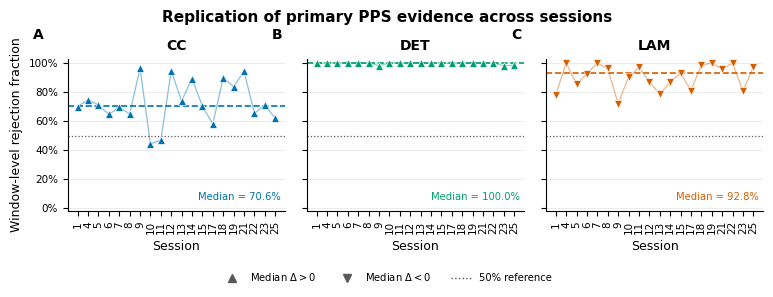

In [6]:
# Cell 6 — Rejection fraction của primary metrics ổn định đến đâu giữa các session?
with plt.rc_context(publication_style):
    fig, axes = plt.subplots(1, 3, figsize=(7.6, 3.05), sharey=True)
    fig.subplots_adjust(left=0.08, right=0.995, bottom=0.27, top=0.77, wspace=0.10)

    for panel, ax, metric in zip("ABC", axes, PRIMARY):
        data = session_metric[session_metric["metric"].eq(metric)].sort_values("session")
        x = np.arange(len(data))
        rejection = data["Rejection fraction"].to_numpy()
        median_rejection = float(np.median(rejection))
        color = METRIC_COLORS[metric]

        ax.plot(x, rejection, color=color, alpha=0.45, linewidth=0.9, zorder=1)
        positive = data["Median delta"].to_numpy() > 0
        negative = data["Median delta"].to_numpy() < 0
        zero = ~(positive | negative)
        ax.scatter(x[positive], rejection[positive], marker="^", color=color, edgecolor="white",
                   linewidth=0.45, s=31, zorder=3)
        ax.scatter(x[negative], rejection[negative], marker="v", color=color, edgecolor="white",
                   linewidth=0.45, s=31, zorder=3)
        ax.scatter(x[zero], rejection[zero], marker="o", facecolor="white", edgecolor=color,
                   linewidth=0.8, s=25, zorder=3)
        ax.axhline(0.5, color="0.35", linestyle=":", linewidth=0.9)
        ax.axhline(median_rejection, color=color, linestyle="--", linewidth=1.2)
        ax.text(-0.16, 1.13, panel, transform=ax.transAxes, fontweight="bold", fontsize=10)
        ax.text(0.98, 0.06, f"Median = {median_rejection:.1%}", transform=ax.transAxes,
                ha="right", va="bottom", fontsize=7.2, color=color)
        ax.set_xticks(x, data["session"].astype(int).astype(str), rotation=90)
        ax.set_title(metric, fontweight="bold")
        ax.set_xlabel("Session")
        ax.set_ylim(-0.02, 1.03)
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", color="0.91", linewidth=0.6)
        ax.set_axisbelow(True)

    axes[0].set_ylabel("Window-level rejection fraction")
    fig.suptitle("Replication of primary PPS evidence across sessions", y=0.93,
                 fontsize=11, fontweight="bold")
    fig.legend(
        handles=[
            Line2D([0], [0], marker="^", color="0.35", linestyle="None", label=r"Median $\Delta>0$", markersize=6),
            Line2D([0], [0], marker="v", color="0.35", linestyle="None", label=r"Median $\Delta<0$", markersize=6),
            Line2D([0], [0], color="0.35", linestyle=":", label="50% reference", linewidth=1),
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, 0.005),
        ncol=3,
        frameon=False,
        fontsize=7.2,
    )
    save_publication_figure(fig, "figure2_session_replication")
    plt.show()

In [7]:
# Cell 7 — Có session nào đảo chiều scientific effect không (không xét p-value)?
session_directions = session_metric[["session", "metric", "Median delta"]].copy()
session_directions["Session direction"] = np.select(
    [session_directions["Median delta"].gt(0), session_directions["Median delta"].lt(0)],
    ["positive", "negative"], default="zero"
)
direction_rows = []
for metric in METRICS:
    values = session_directions.loc[
        session_directions["metric"].eq(metric), "Session direction"
    ]
    counts = values.value_counts()
    n_positive = int(counts.get("positive", 0))
    n_negative = int(counts.get("negative", 0))
    n_zero = int(counts.get("zero", 0))
    direction_rows.append(
        {
            "Metric": metric,
            "Sessions positive": n_positive,
            "Sessions negative": n_negative,
            "Sessions zero": n_zero,
            "Dominant direction": dominant_direction(n_positive, n_negative, n_zero),
        }
    )
session_direction_summary = pd.DataFrame(direction_rows)
display(session_direction_summary)

,Metric,Sessions positive,Sessions negative,Sessions zero,Dominant direction
0,CC,20,0,0,positive
1,DET,20,0,0,positive
2,LAM,0,20,0,negative
3,NRMSE,0,20,0,negative
4,Lmean,20,0,0,positive
5,ENTR,20,0,0,positive
6,Lmax,20,0,0,positive
7,TT,0,20,0,negative
8,Vmax,0,18,2,negative


In [8]:
# Cell 8 — Cả Awake và Drowsy đều lệch PPS null hay chỉ một state?
state_metric = summarize_long(metric_long, ["state", "metric"])
state_metric["_metric_order"] = state_metric["metric"].map({m: i for i, m in enumerate(METRICS)})
state_metric = state_metric.sort_values(["_metric_order", "state"]).drop(columns="_metric_order")
state_descriptive = state_metric[
    ["state", "metric", "N", "Rejection fraction", "Median delta", "IQR delta",
     "Direction consistency", "Dominant direction"]
]
display(state_descriptive.reset_index(drop=True).round(4))
print("Descriptive only: no pooled-window Awake-vs-Drowsy inference is performed.")

,state,metric,N,Rejection fraction,Median delta,IQR delta,Direction consistency,Dominant direction
0,Awake,CC,1026,0.6979,0.1155,0.0962,0.9932,positive
1,Drowsy,CC,518,0.8224,0.1514,0.1126,0.9981,positive
2,Awake,DET,1026,0.9971,0.1738,0.0455,1.0000,positive
3,Drowsy,DET,518,0.9961,0.1834,0.0463,1.0000,positive
4,Awake,LAM,1026,0.9035,-0.1124,0.0630,0.9893,negative
5,Drowsy,LAM,518,0.8900,-0.1127,0.0676,0.9788,negative
6,Awake,NRMSE,1026,0.9405,-0.1410,0.0697,0.9981,negative
7,Drowsy,NRMSE,518,0.9691,-0.1647,0.0770,1.0000,negative
8,Awake,Lmean,1026,0.9942,1.1158,0.2333,1.0000,positive
9,Drowsy,Lmean,518,0.9961,1.1133,0.2015,0.9961,positive


Descriptive only: no pooled-window Awake-vs-Drowsy inference is performed.


,Metric,N paired sessions,Median state contrast,Sessions Drowsy > Awake,Sessions Drowsy < Awake,Sessions tied
0,CC,20,0.0247,17,3,0
1,DET,20,-0.0003,10,10,0
2,LAM,20,0.0012,12,8,0


Saved publication figure: /home/vutu0809/Desktop/NTSA_Foundation/phase1/results/statistic/validation/figure3_paired_state_contrast.pdf
Saved publication figure: /home/vutu0809/Desktop/NTSA_Foundation/phase1/results/statistic/validation/figure3_paired_state_contrast.png


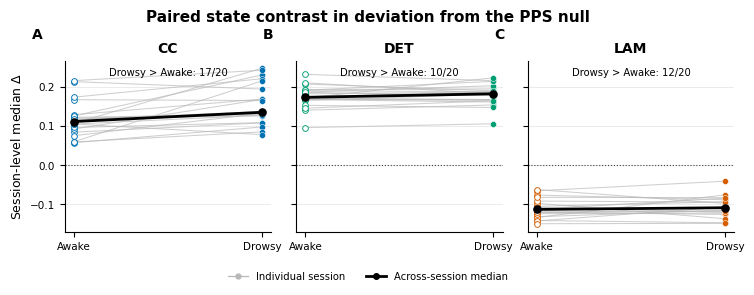

In [9]:
# Cell 9 — Drowsiness có làm mức deviation khỏi PPS null thay đổi nhất quán theo session không?
session_state_metric = summarize_long(metric_long, ["session", "state", "metric"])
paired = (
    session_state_metric[session_state_metric["metric"].isin(PRIMARY)]
    .pivot(index=["session", "metric"], columns="state", values="Median delta")
    .reset_index()
)
required_states = ["Awake", "Drowsy"]
missing_states = [state for state in required_states if state not in paired.columns]
if missing_states:
    raise ValueError(f"Required state labels absent from data: {missing_states}")
paired = paired.dropna(subset=required_states).copy()
paired["State contrast"] = paired["Drowsy"] - paired["Awake"]

contrast_rows = []
for metric in PRIMARY:
    values = paired.loc[paired["metric"].eq(metric), "State contrast"].to_numpy()
    contrast_rows.append(
        {
            "Metric": metric,
            "N paired sessions": len(values),
            "Median state contrast": float(np.median(values)),
            "Sessions Drowsy > Awake": int(np.sum(values > 0)),
            "Sessions Drowsy < Awake": int(np.sum(values < 0)),
            "Sessions tied": int(np.sum(values == 0)),
        }
    )
state_contrast_summary = pd.DataFrame(contrast_rows)
display(state_contrast_summary.round(4))

with plt.rc_context(publication_style):
    fig, axes = plt.subplots(1, 3, figsize=(7.4, 3.0), sharey=True)
    fig.subplots_adjust(left=0.09, right=0.995, bottom=0.19, top=0.76, wspace=0.12)

    for panel, ax, metric in zip("ABC", axes, PRIMARY):
        data = paired[paired["metric"].eq(metric)].sort_values("session")
        for _, row in data.iterrows():
            ax.plot([0, 1], [row["Awake"], row["Drowsy"]], color="0.72", alpha=0.68,
                    linewidth=0.75, zorder=1)
            ax.scatter([0], [row["Awake"]], facecolor="white", edgecolor=METRIC_COLORS[metric],
                       linewidth=0.65, s=17, zorder=2)
            ax.scatter([1], [row["Drowsy"]], color=METRIC_COLORS[metric], edgecolor="white",
                       linewidth=0.35, s=19, zorder=2)

        state_medians = data[["Awake", "Drowsy"]].median()
        ax.plot([0, 1], state_medians, color="black", linewidth=2.0, zorder=4)
        ax.scatter([0, 1], state_medians, color="black", s=27, zorder=5)
        n_greater = int((data["State contrast"] > 0).sum())
        ax.axhline(0, color="0.25", linewidth=0.8, linestyle=":")
        ax.text(-0.16, 1.13, panel, transform=ax.transAxes, fontweight="bold", fontsize=10)
        ax.text(0.5, 0.96, f"Drowsy > Awake: {n_greater}/{len(data)}", transform=ax.transAxes,
                ha="center", va="top", fontsize=7.2)
        ax.set_xticks([0, 1], required_states)
        ax.set_title(metric, fontweight="bold")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", color="0.91", linewidth=0.6)
        ax.set_axisbelow(True)

    axes[0].set_ylabel(r"Session-level median $\Delta$")
    fig.suptitle("Paired state contrast in deviation from the PPS null", y=0.93,
                 fontsize=11, fontweight="bold")
    fig.legend(
        handles=[
            Line2D([0], [0], color="0.72", linewidth=0.9, marker="o", markersize=3.5,
                   label="Individual session"),
            Line2D([0], [0], color="black", linewidth=2.0, marker="o", markersize=4,
                   label="Across-session median"),
        ],
        loc="lower center",
        bbox_to_anchor=(0.5, -0.005),
        ncol=2,
        frameon=False,
        fontsize=7.2,
    )
    save_publication_figure(fig, "figure3_paired_state_contrast")
    plt.show()

,window_size,metric,N,Rejection fraction,Median delta,Direction consistency,Dominant direction
0,60,CC,901,0.6693,0.1351,0.9922,positive
1,120,CC,405,0.8296,0.1169,0.9975,positive
2,180,CC,238,0.8529,0.1195,1.0000,positive
3,60,DET,901,0.9989,0.1816,1.0000,positive
4,120,DET,405,0.9926,0.1726,1.0000,positive
5,180,DET,238,0.9958,0.1659,1.0000,positive
6,60,LAM,901,0.8990,-0.1259,0.9878,negative
7,120,LAM,405,0.9012,-0.1018,0.9827,negative
8,180,LAM,238,0.8950,-0.0901,0.9832,negative
9,60,NRMSE,901,0.9245,-0.1528,0.9989,negative


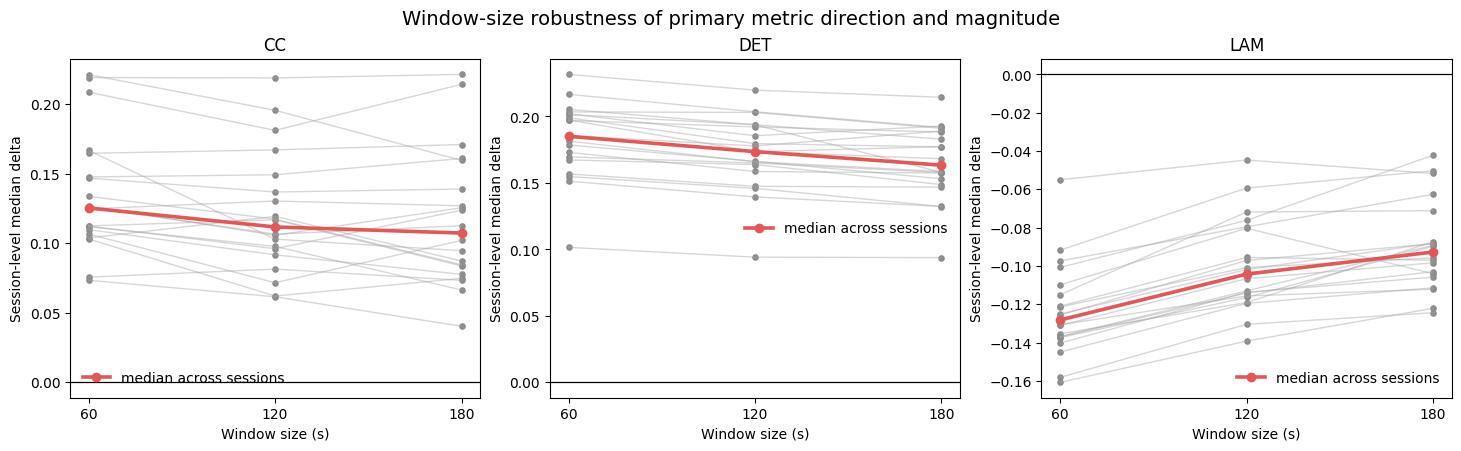

In [10]:
# Cell 10 — Evidence có phụ thuộc window length 60/120/180 s không?
window_metric = summarize_long(metric_long, ["window_size", "metric"])
window_metric["_metric_order"] = window_metric["metric"].map({m: i for i, m in enumerate(METRICS)})
window_metric = window_metric.sort_values(["_metric_order", "window_size"]).drop(columns="_metric_order")
display(
    window_metric[["window_size", "metric", "N", "Rejection fraction", "Median delta",
                   "Direction consistency", "Dominant direction"]].reset_index(drop=True).round(4)
)

session_window_metric = summarize_long(metric_long, ["session", "window_size", "metric"])
window_sizes = sorted(metric_long["window_size"].unique())
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4), constrained_layout=True)
for ax, metric in zip(axes, PRIMARY):
    data = session_window_metric[session_window_metric["metric"].eq(metric)]
    for _, group in data.groupby("session", observed=True):
        group = group.sort_values("window_size")
        ax.plot(group["window_size"], group["Median delta"], color="0.65", alpha=0.45,
                linewidth=1)
        ax.scatter(group["window_size"], group["Median delta"], color="0.55", s=14)
    overall = data.groupby("window_size", observed=True)["Median delta"].median().reindex(window_sizes)
    ax.plot(window_sizes, overall, color="#E45756", marker="o", linewidth=2.6,
            label="median across sessions")
    ax.axhline(0, color="black", linewidth=0.9)
    ax.set_xticks(window_sizes)
    ax.set(title=metric, xlabel="Window size (s)", ylabel="Session-level median delta")
    ax.legend(frameon=False)
fig.suptitle("Window-size robustness of primary metric direction and magnitude", fontsize=14)
plt.show()

In [11]:
# Cell 11 — Primary integrated evidence cho RQ1 là gì?
integrated_rows = []
n_sessions = windows_all["session"].nunique()
for metric in PRIMARY:
    overall = global_summary.set_index("metric").loc[metric]
    dominant = overall["Dominant direction"]
    session_dirs = session_directions.loc[
        session_directions["metric"].eq(metric), "Session direction"
    ]
    same_count = int(session_dirs.eq(dominant).sum())
    state_lookup = state_metric[state_metric["metric"].eq(metric)].set_index("state")
    window_lookup = window_metric[window_metric["metric"].eq(metric)].set_index("window_size")
    integrated_rows.append(
        {
            "Metric": metric,
            "Overall rejection": overall["Rejection fraction"],
            "Direction consistency": overall["Direction consistency"],
            "Sessions same direction": f"{same_count}/{n_sessions}",
            "Awake rejection": state_lookup.loc["Awake", "Rejection fraction"],
            "Drowsy rejection": state_lookup.loc["Drowsy", "Rejection fraction"],
            "60 s": window_lookup.loc[60, "Rejection fraction"],
            "120 s": window_lookup.loc[120, "Rejection fraction"],
            "180 s": window_lookup.loc[180, "Rejection fraction"],
        }
    )
primary_integrated = pd.DataFrame(integrated_rows)
display(primary_integrated.round(4))

,Metric,Overall rejection,Direction consistency,Sessions same direction,Awake rejection,Drowsy rejection,60 s,120 s,180 s
0,CC,0.7396,0.9948,20/20,0.6979,0.8224,0.6693,0.8296,0.8529
1,DET,0.9968,1.0000,20/20,0.9971,0.9961,0.9989,0.9926,0.9958
2,LAM,0.8990,0.9858,20/20,0.9035,0.8900,0.8990,0.9012,0.8950


In [12]:
# Cell 12 — Secondary metrics có hỗ trợ primary finding không?
secondary_rows = []
global_lookup = global_summary.set_index("metric")
session_direction_lookup = session_direction_summary.set_index("Metric")
for metric in SECONDARY:
    dominant = global_lookup.loc[metric, "Dominant direction"]
    n_same = int(
        session_directions.loc[session_directions["metric"].eq(metric), "Session direction"]
        .eq(dominant).sum()
    )
    secondary_rows.append(
        {
            "Metric": metric,
            "Overall rejection fraction": global_lookup.loc[metric, "Rejection fraction"],
            "Direction consistency": global_lookup.loc[metric, "Direction consistency"],
            "Median delta": global_lookup.loc[metric, "Median delta"],
            "Dominant direction": dominant,
            "Sessions same dominant direction": f"{n_same}/{n_sessions}",
        }
    )
secondary_summary = pd.DataFrame(secondary_rows)
display(secondary_summary.round(4))

,Metric,Overall rejection fraction,Direction consistency,Median delta,Dominant direction,Sessions same dominant direction
0,NRMSE,0.9501,0.9987,-0.1471,negative,20/20
1,Lmean,0.9948,0.9987,1.1143,positive,20/20
2,ENTR,0.9890,0.9987,0.3374,positive,20/20
3,Lmax,0.9190,0.9987,55.0000,positive,20/20
4,TT,0.9702,0.9974,-0.1058,negative,20/20
5,Vmax,0.2960,0.6095,-1.0000,negative,18/20


,session,representation,state,window_size_s,window_id
0,22,Processed,Awake,60,18
1,6,Processed,Awake,120,15
2,1,Processed,Awake,180,5
3,14,Processed,Drowsy,60,49
4,11,Processed,Drowsy,120,7
5,12,Processed,Drowsy,180,10


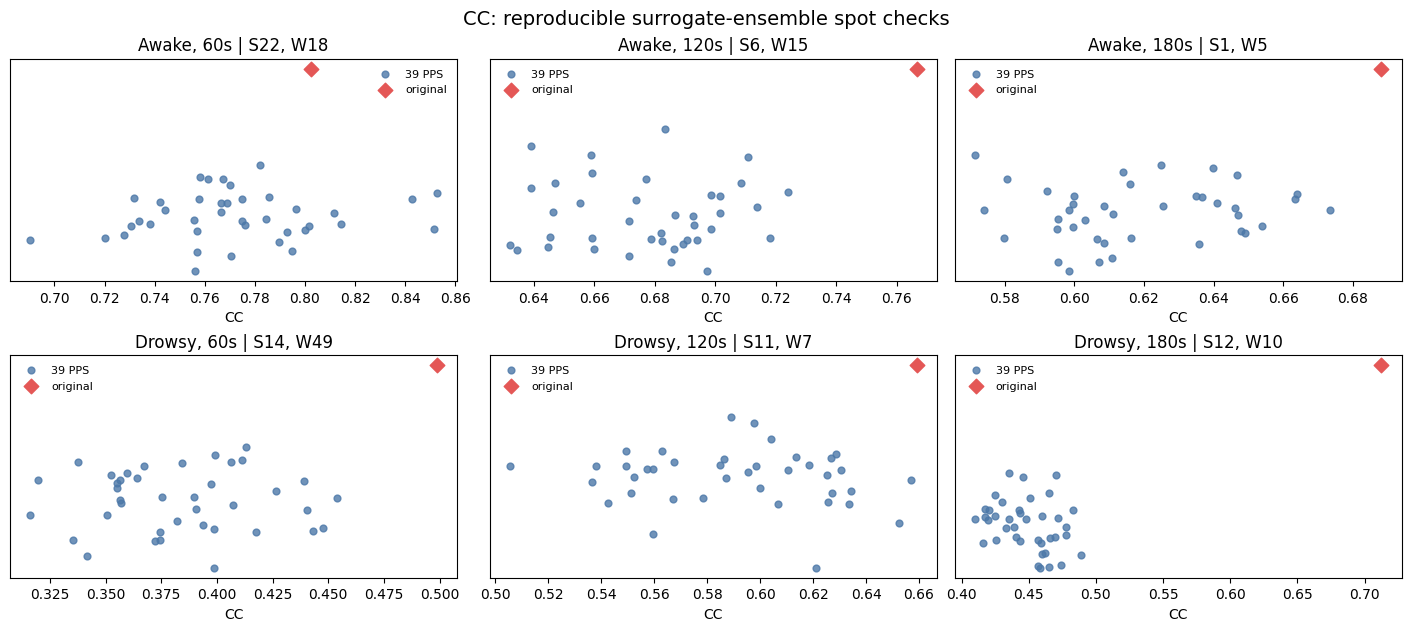

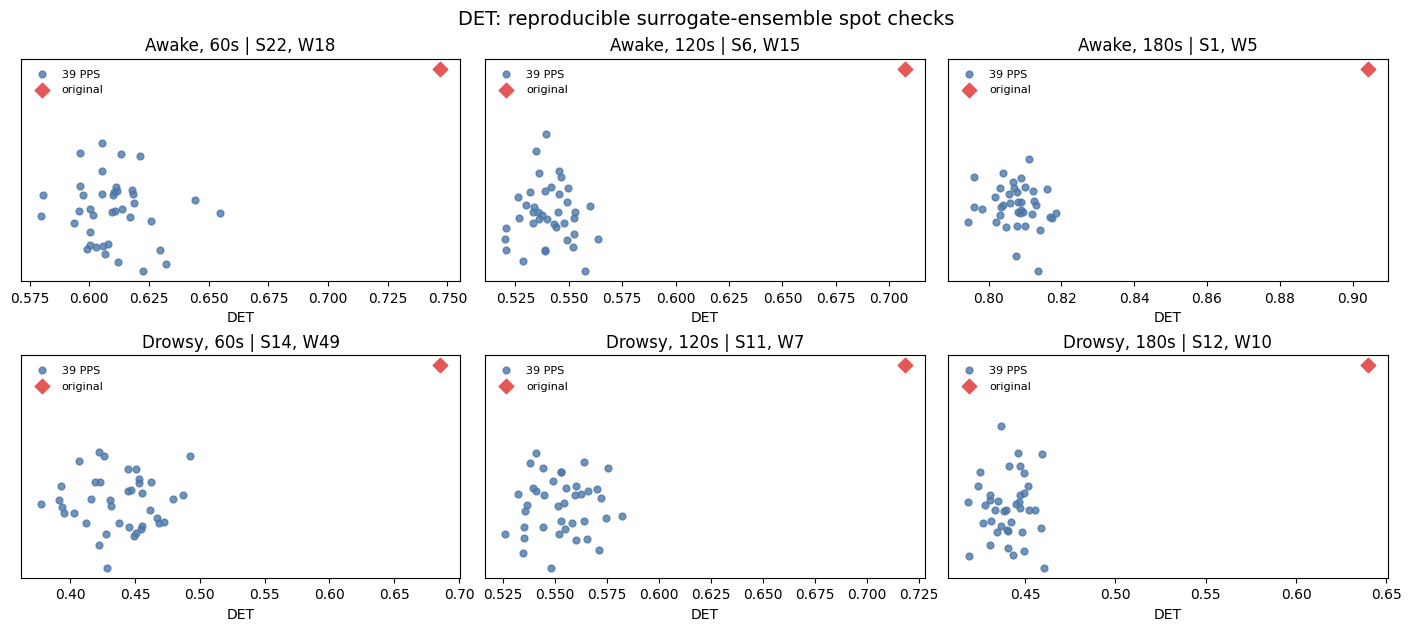

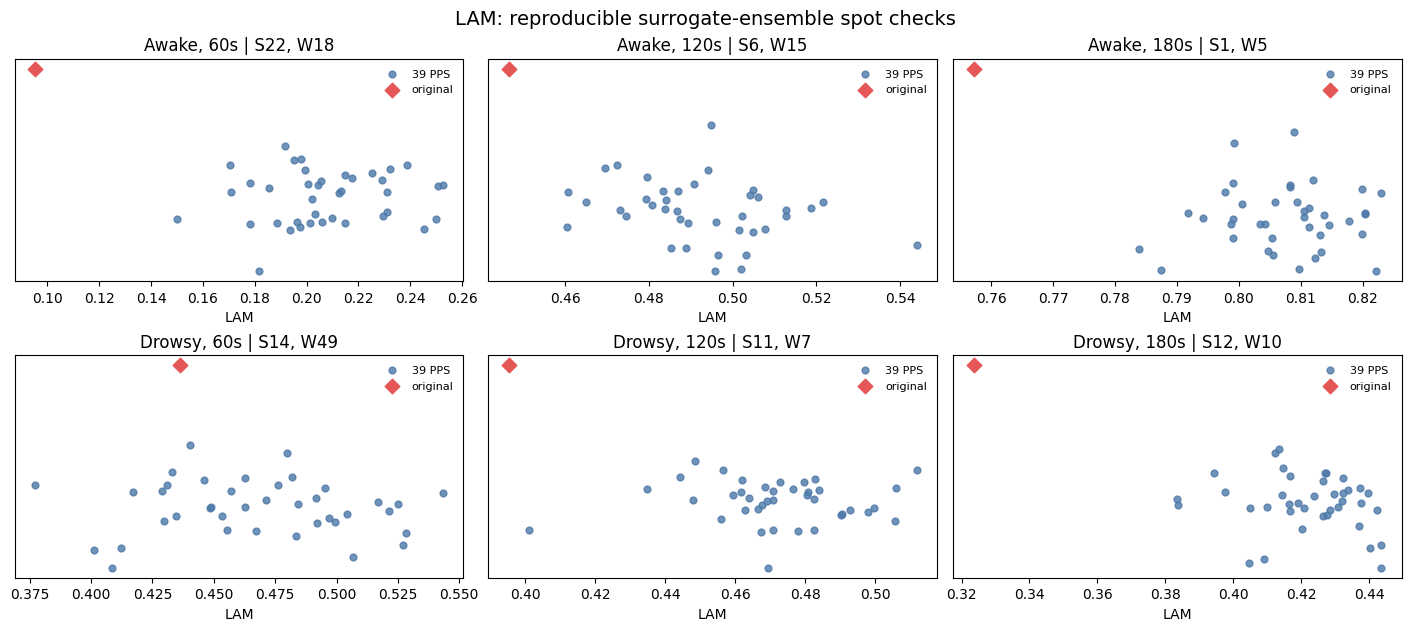

In [13]:
# Cell 14 — Rank-test result có phản ánh vị trí original so với 39-member ensemble không?
# Cell 13 (tie-safe RQA diagnostic) is intentionally omitted: neither result schema contains
# epsilon, exact-unachievable RR, achieved_rr, or zero-distance diagnostic fields.
rng = np.random.default_rng(2026)
selected_rows = []
for state in ["Awake", "Drowsy"]:
    for window_size in [60, 120, 180]:
        candidates = windows_all[
            windows_all["state"].eq(state) & windows_all["window_size"].eq(window_size)
        ]
        if candidates.empty:
            continue
        selected_rows.append(candidates.loc[rng.choice(candidates.index), WINDOW_KEYS])
selected_spot = pd.DataFrame(selected_rows).reset_index(drop=True)
display(selected_spot.rename(columns={"window_size": "window_size_s"}))

spot_surrogates = surrogates_all.merge(selected_spot, on=WINDOW_KEYS, how="inner", validate="many_to_one")
spot_windows = windows_all.merge(selected_spot, on=WINDOW_KEYS, how="inner", validate="one_to_one")
jitter_rng = np.random.default_rng(2026)
for metric in PRIMARY:
    fig, axes = plt.subplots(2, 3, figsize=(14, 6.2), constrained_layout=True)
    for row_i, state in enumerate(["Awake", "Drowsy"]):
        for col_i, window_size in enumerate([60, 120, 180]):
            ax = axes[row_i, col_i]
            key = selected_spot[
                selected_spot["state"].eq(state)
                & selected_spot["window_size"].eq(window_size)
            ]
            if key.empty:
                ax.set_axis_off()
                continue
            key_values = key.iloc[0]
            mask_s = np.logical_and.reduce(
                [spot_surrogates[column].eq(key_values[column]) for column in WINDOW_KEYS]
            )
            mask_w = np.logical_and.reduce(
                [spot_windows[column].eq(key_values[column]) for column in WINDOW_KEYS]
            )
            surrogate_values = spot_surrogates.loc[mask_s, metric].to_numpy()
            original_value = spot_windows.loc[mask_w, f"{metric}_original"].iloc[0]
            y = jitter_rng.normal(0, 0.025, len(surrogate_values))
            ax.scatter(surrogate_values, y, color="#4C78A8", alpha=0.8, s=24,
                       label="39 PPS")
            ax.scatter([original_value], [0.13], marker="D", color="#E45756", s=55,
                       label="original", zorder=4)
            ax.set(title=f"{state}, {window_size}s | S{int(key_values['session'])}, "
                         f"W{int(key_values['window_id'])}", xlabel=metric, yticks=[])
            ax.legend(frameon=False, fontsize=8)
    fig.suptitle(f"{metric}: reproducible surrogate-ensemble spot checks", fontsize=14)
    plt.show()

In [14]:
# Cell 15 — Kết luận session-weighted (không để session nhiều window chi phối) là gì?
weighted_rows = []
for metric in METRICS:
    data = session_metric[session_metric["metric"].eq(metric)]
    rejection = data["Rejection fraction"].to_numpy()
    delta = data["Median delta"].to_numpy()
    weighted_rows.append(
        {
            "Metric": metric,
            "N sessions": len(data),
            "Median session rejection": float(np.median(rejection)),
            "IQR session rejection": float(np.quantile(rejection, 0.75) - np.quantile(rejection, 0.25)),
            "Median session delta": float(np.median(delta)),
            "IQR session delta": float(np.quantile(delta, 0.75) - np.quantile(delta, 0.25)),
        }
    )
session_weighted_summary = pd.DataFrame(weighted_rows)
display(session_weighted_summary.round(4))

,Metric,N sessions,Median session rejection,IQR session rejection,Median session delta,IQR session delta
0,CC,20,0.7063,0.2025,0.1208,0.0414
1,DET,20,1.0000,0.0000,0.1815,0.0289
2,LAM,20,0.9283,0.1310,-0.1154,0.0242
3,NRMSE,20,0.9541,0.0672,-0.1378,0.0515
4,Lmean,20,1.0000,0.0035,1.1341,0.1259
5,ENTR,20,1.0000,0.0137,0.3548,0.0819
6,Lmax,20,0.9292,0.0709,53.7500,12.3750
7,TT,20,0.9856,0.0478,-0.1071,0.0504
8,Vmax,20,0.3181,0.2295,-1.0000,0.0000


In [15]:
# Cell 16 — Final RQ1 synthesis (không thêm statistical test mới)
global_lookup = global_summary.set_index("metric")
primary_ranked = global_lookup.loc[PRIMARY].sort_values("Rejection fraction", ascending=False)
strongest = ", ".join(
    f"{metric} ({row['Rejection fraction']:.1%})" for metric, row in primary_ranked.iterrows()
)
primary_directions = ", ".join(
    f"{m}: {global_lookup.loc[m, 'Dominant direction']} "
    f"({global_lookup.loc[m, 'Direction consistency']:.1%})" for m in PRIMARY
)
replication_bits = []
for metric in PRIMARY:
    dominant = global_lookup.loc[metric, "Dominant direction"]
    same = session_directions.loc[session_directions["metric"].eq(metric), "Session direction"].eq(dominant).sum()
    replication_bits.append(f"{metric} {same}/{n_sessions}")
state_bits = []
for metric in PRIMARY:
    lookup = state_metric[state_metric["metric"].eq(metric)].set_index("state")
    state_bits.append(
        f"{metric} Awake {lookup.loc['Awake', 'Rejection fraction']:.1%}, "
        f"Drowsy {lookup.loc['Drowsy', 'Rejection fraction']:.1%}"
    )
contrast_bits = []
for _, row in state_contrast_summary.iterrows():
    contrast_bits.append(
        f"{row['Metric']} median={row['Median state contrast']:.3g}, "
        f"Drowsy>Awake {int(row['Sessions Drowsy > Awake'])}/{int(row['N paired sessions'])}"
    )
robustness_bits = []
for metric in PRIMARY:
    values = window_metric[window_metric["metric"].eq(metric)].sort_values("window_size")
    robustness_bits.append(
        f"{metric} rejection {values['Rejection fraction'].min():.1%}–"
        f"{values['Rejection fraction'].max():.1%}; directions "
        f"{', '.join(values['Dominant direction'].astype(str))}"
    )

synthesis = [
    "1. Processed PPG vs PPS null: primary metrics reject in a substantial fraction of windows: " + strongest + ".",
    "2. Strongest primary evidence (ranked by rejection fraction): " + strongest + ".",
    "3. Window-level direction: " + primary_directions + ".",
    "4. Replication in the dataset-wide dominant direction across sessions: " + "; ".join(replication_bits) + ".",
    "5. Evidence by state: " + "; ".join(state_bits) + ".",
    "6. Paired Drowsy − Awake session contrasts: " + "; ".join(contrast_bits) + ". This is descriptive, not a new inferential test.",
    "7. Window-size robustness (60/120/180 s): " + "; ".join(robustness_bits) + ".",
    "8. Numerical QC: all global integrity checks passed. Tie-safe RQA prevalence cannot be assessed because the production result schemas do not contain the required diagnostic fields.",
]
print("\n".join(synthesis))
print("\nConclusion: Evidence that the observed processed PPG contains dynamical organization "
      "not captured by the tested noisy pseudoperiodic PPS null.")

1. Processed PPG vs PPS null: primary metrics reject in a substantial fraction of windows: DET (99.7%), LAM (89.9%), CC (74.0%).
2. Strongest primary evidence (ranked by rejection fraction): DET (99.7%), LAM (89.9%), CC (74.0%).
3. Window-level direction: CC: positive (99.5%), DET: positive (100.0%), LAM: negative (98.6%).
4. Replication in the dataset-wide dominant direction across sessions: CC 20/20; DET 20/20; LAM 20/20.
5. Evidence by state: CC Awake 69.8%, Drowsy 82.2%; DET Awake 99.7%, Drowsy 99.6%; LAM Awake 90.4%, Drowsy 89.0%.
6. Paired Drowsy − Awake session contrasts: CC median=0.0247, Drowsy>Awake 17/20; DET median=-0.000306, Drowsy>Awake 10/20; LAM median=0.00123, Drowsy>Awake 12/20. This is descriptive, not a new inferential test.
7. Window-size robustness (60/120/180 s): CC rejection 66.9%–85.3%; directions positive, positive, positive; DET rejection 99.3%–99.9%; directions positive, positive, positive; LAM rejection 89.5%–90.1%; directions negative, negative, negative.


## Tổng kết kết quả đạt được — 20 sessions

- Dataset hoàn chỉnh gồm **20 sessions, 1.544 windows và 60.216 surrogate rows**;
  số surrogate khớp chính xác $1.544\times39$. Tất cả integrity checks đều
  **PASS**: định danh window duy nhất và khớp giữa hai bảng, đủ 39 PPS/window,
  `surrogate_id` và seed duy nhất trong từng window, toàn bộ metrics/p-values hữu
  hạn, và `M == 39`.
- Ở window level, **DET** cho evidence mạnh nhất (reject **99,68%**), tiếp theo
  **LAM 89,90%** và **CC 73,96%**. Hướng $\Delta$ chiếm ưu thế là DET dương
  (100,00% windows), CC dương (99,48%) và LAM âm (98,58%).
- Hướng effect replicate ở **20/20 sessions** cho cả ba primary metrics. Summary
  session-weighted cũng giữ kết luận: median session rejection là **70,63%**
  (CC), **100,00%** (DET) và **92,83%** (LAM); median session $\Delta$ tương ứng
  là 0,1208, 0,1815 và −0,1154.
- Evidence xuất hiện ở cả hai state. Awake/Drowsy rejection là
  **69,79%/82,24%** (CC), **99,71%/99,61%** (DET) và **90,35%/89,00%** (LAM).
  Paired Drowsy − Awake median $\Delta$ là 0,0247 (CC; 17/20 sessions dương),
  −0,0003 (DET; 10/20) và 0,0012 (LAM; 12/20). Đây là mô tả paired, không phải
  một inferential test mới.
- Hướng effect không đổi qua 60/120/180 s. Rejection range theo window size là
  **66,93–85,29%** (CC), **99,26–99,89%** (DET) và **89,50–90,12%** (LAM).
- NRMSE, Lmean, ENTR, Lmax và TT hỗ trợ mạnh, replicate đúng hướng ở 20/20
  sessions; Vmax yếu hơn (reject 29,60%, direction consistency 60,95%, 18/20
  sessions theo hướng âm).
- Ba figure chính được lưu publication-ready dưới dạng **PDF vector** và **PNG
  600 dpi** trong `phase1/results/statistic/validation`: primary delta
  distributions, session replication và paired state contrast. Các diagnostic
  figure khác chỉ hiển thị inline.
- Diagnostic tie-safe RQA chuyên biệt chưa thể đánh giá vì production schemas
  không có các field `epsilon`, `achieved_rr`, exact-unachievable RR hoặc
  zero-distance tương ứng.

**Kết luận trong phạm vi PPS null đã kiểm tra:** Evidence that the observed
processed PPG contains dynamical organization not captured by the tested noisy
pseudoperiodic PPS null.

## Kết luận RQ1 — PPS Surrogate Testing

Processed PPG cho thấy sự lệch nhất quán khỏi noisy pseudoperiodic PPS null.

Kết quả chính:

```text
CC   ↑ so với PPS   | reject ≈ 74%
DET  ↑ so với PPS   | reject ≈ 99,7%
LAM  ↓ so với PPS   | reject ≈ 89,9%
````

Hướng effect được lặp lại ở **20/20 sessions**, ổn định giữa Awake/Drowsy và các window 60/120/180 s.

Các metric phụ cũng hỗ trợ cùng một pattern:

```text
NRMSE ↓
Lmean ↑
ENTR  ↑
Lmax  ↑
TT    ↓
```

Do đó:

> **Processed PPG chứa tổ chức động lực học không được giải thích đầy đủ bởi noisy pseudoperiodic PPS null đã kiểm tra.**

RQ1 hiện đã được hỗ trợ đủ mạnh bởi surrogate testing. Phân tích Lyapunov có thể bổ sung bằng chứng về local trajectory divergence, nhưng không phải điều kiện bắt buộc cho kết luận này.

Kết quả này **không đồng nghĩa với việc chứng minh deterministic chaos**.


## Insight & Findings chính

- **Processed PPG khác PPS null một cách rất nhất quán**, không chỉ ở pooled windows mà còn lặp lại qua **20/20 sessions**.

- Signature động lực học nổi bật:
  - `CC ↑`, `NRMSE ↓` → original có **forecastability tốt hơn PPS**.
  - `DET ↑`, `Lmean ↑`, `ENTR ↑`, `Lmax ↑` → original có **diagonal recurrence organization mạnh và giàu cấu trúc hơn**.
  - `LAM ↓`, `TT ↓` → original có **ít laminar/vertical persistence hơn PPS**.

- `DET` là metric mạnh nhất, gần như reject PPS ở toàn bộ windows; `LAM` cũng rất mạnh; `CC` yếu hơn về rejection nhưng gần như tuyệt đối nhất quán về hướng.

- Evidence xuất hiện ở cả **Awake và Drowsy**, cho thấy nonlinear organization vượt PPS null là một đặc tính nền của processed PPG, không chỉ xuất hiện khi buồn ngủ.

- State modulation có vẻ rõ hơn ở **prediction structure** (`CC`) so với recurrence structure (`DET`, `LAM`).

- Pattern ổn định ở **60/120/180 s**, cho thấy kết luận không phụ thuộc mạnh vào window length.

- `Vmax` yếu và kém ổn định hơn, nên không nên dùng làm bằng chứng chính.

> **Finding tổng quát:** processed PPG không chỉ mang tính pseudoperiodic đơn giản; nó chứa tổ chức động lực học tinh hơn, đặc biệt ở khả năng dự báo và cấu trúc recurrence.
